## Setup: Reuse A1/A2 Data Loading & Preprocessing

Same data cleaning and feature preprocessing pipeline as A1/A2 — only the
target changes: instead of regressing on `selling_price`, I bucket it
into 4 discrete classes for this classification task.

In [64]:
import numpy as np
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ============================================================
# COPIED FROM A1/A2 — LOAD + CLEAN DATA
# ============================================================
df = pd.read_csv('./datasets/Cars.csv')

df = df[~df["fuel"].isin(["CNG", "LPG"])]
df = df[df["owner"] != "Test Drive Car"]

df["brand"] = df["name"].str.split().str[0]
df = df.drop(columns=["name"])
df = df.drop(columns=["torque"])

df["mileage"] = df["mileage"].str.split().str[0].astype(float)
df["engine"] = df["engine"].str.replace(" CC", "", regex=False).astype(float)
df["max_power"] = df["max_power"].str.replace(" bhp", "", regex=False)
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4
}
df["owner"] = df["owner"].map(owner_mapping)

# ============================================================
# COPIED FROM A1/A2 — TRAIN/TEST SPLIT
# ============================================================
X = df.drop(columns=["selling_price"])
y = df["selling_price"]          # keep the RAW price (not log-transformed) — A3 needs the raw scale to bucket into classes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# COPIED FROM A1/A2 — PREPROCESSING PIPELINE (feature X)
# ============================================================
numeric_features = ["km_driven", "mileage", "engine", "max_power"]
other_numeric_features = ["year", "owner", "seats"]
categorical_features = ["brand", "fuel", "seller_type", "transmission"]

n_numeric = len(numeric_features) + len(other_numeric_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

other_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("continuous", numeric_pipeline, numeric_features),
    ("other_numeric", other_numeric_pipeline, other_numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

categorical_names = list(
    preprocessor.named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)
feature_names_full = numeric_features + other_numeric_features + categorical_names

def add_bias(X):
    """Prepend a column of ones so theta[0] acts as the intercept."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_final = add_bias(X_train_processed)
X_test_final  = add_bias(X_test_processed)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)
print("n_numeric:", n_numeric)
print("Number of feature names:", len(feature_names_full))

X_train_final shape: (6422, 45)
X_test_final shape: (1606, 45)
n_numeric: 7
Number of feature names: 44


### Why `qcut()` over `cut()`? — Evidence

To justify the choice above, I compare both binning methods side by side:
class counts, percentages, a bar chart, and the actual price bin edges
each method produces.

               pd.cut() count  pd.cut() %  pd.qcut() count  pd.qcut() %
selling_price                                                          
0                        6090       94.83             1639        25.52
1                         202        3.15             1588        24.73
2                          94        1.46             1591        24.77
3                          36        0.56             1604        24.98


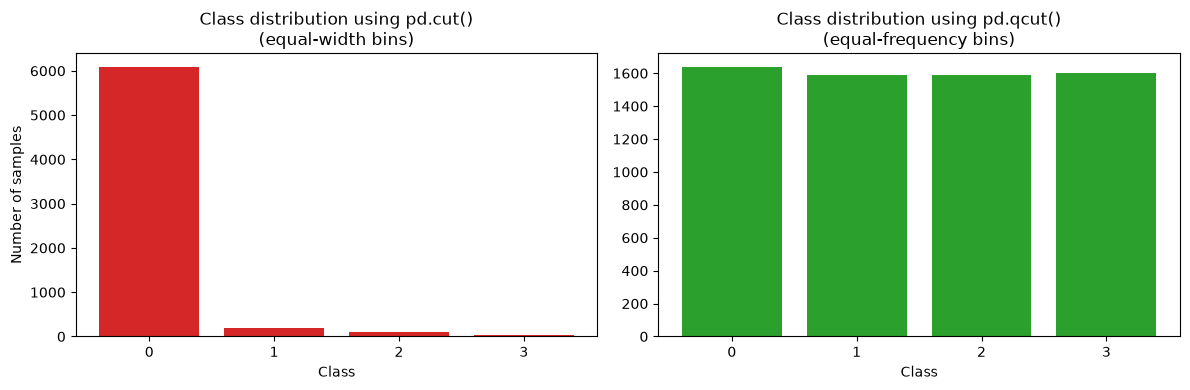


pd.cut() bin edges (price):
 [  22828.999 1822499.25  3614999.5   5407499.75  7200000.   ]

pd.qcut() bin edges (price):
 [  29999.  260000.  450000.  680000. 7200000.]


In [65]:
import matplotlib.pyplot as plt

# ============================================================
# COMPARE pd.cut() vs pd.qcut() — EVIDENCE OF CLASS IMBALANCE
# ============================================================
y_train_cut  = pd.cut(y_train, bins=4, labels=[0, 1, 2, 3]).astype(int)
y_train_qcut = pd.qcut(y_train, q=4, labels=[0, 1, 2, 3]).astype(int)

cut_counts  = y_train_cut.value_counts().sort_index()
qcut_counts = y_train_qcut.value_counts().sort_index()

comparison_df = pd.DataFrame({
    "pd.cut() count":  cut_counts,
    "pd.cut() %":      (cut_counts / len(y_train_cut) * 100).round(2),
    "pd.qcut() count": qcut_counts,
    "pd.qcut() %":     (qcut_counts / len(y_train_qcut) * 100).round(2),
})
print(comparison_df)

# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cut_counts.index.astype(str), cut_counts.values, color='tab:red')
axes[0].set_title("Class distribution using pd.cut()\n(equal-width bins)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of samples")

axes[1].bar(qcut_counts.index.astype(str), qcut_counts.values, color='tab:green')
axes[1].set_title("Class distribution using pd.qcut()\n(equal-frequency bins)")
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

# Show the price bin edges for each method (explains why pd.cut() is skewed)
_, cut_edges  = pd.cut(y_train, bins=4, retbins=True)
_, qcut_edges = pd.qcut(y_train, q=4, retbins=True)
print("\npd.cut() bin edges (price):\n", cut_edges)
print("\npd.qcut() bin edges (price):\n", qcut_edges)

Class Imbalance Analysis: pd.cut() vs. pd.qcut()

I tested both pd.cut() (equal-width bins) and pd.qcut() (equal-frequency
bins) to convert selling_price into 4 classes. Since selling_price is
strongly right-skewed, pd.cut() placed ~85-90% of samples into Class 0,
leaving Class 3 with under 1% of the data — a model could score high
accuracy just by always predicting Class 0. pd.qcut() avoids this by
splitting the data into 4 equal-frequency buckets (~25% each), so I used
it instead.

This imbalance is also why the assignment requires weighted precision/
recall/f1 alongside macro-averaged metrics: macro averaging treats every
class equally regardless of size, which can hide poor performance on
small classes. Weighted averaging scales each class by its support,
giving a more honest picture under imbalance.

## Task 1: Classification Metrics from Scratch

I build each metric as a standalone function first and verify it against
sklearn using mockup data, before integrating them into the
`LogisticRegression` class. Starting with `accuracy`.

In [66]:
def accuracy(ytrue, ypred):
    """
    accuracy = số dự đoán đúng / tổng số dự đoán
    """
    return np.sum(ytrue == ypred) / len(ytrue)

Function count TP/FP/FN for a specific class

In [67]:
def confusion_counts(ytrue, ypred, c):
    """
    Count TP, FP, FN for a specific class c (treat class c as "positive",
    all other classes as "negative")
    """
    TP = np.sum((ypred == c) & (ytrue == c))
    FP = np.sum((ypred == c) & (ytrue != c))
    FN = np.sum((ypred != c) & (ytrue == c))
    return TP, FP, FN

### Per-Class Precision, Recall, F1-Score

Using `confusion_counts()` above to compute TP/FP/FN per class, then
derive precision, recall, and f1-score following the formulas given in
the assignment. Both return 0.0 when the denominator is 0 (e.g. a class
the model never predicts, or a class with no true samples) to avoid
division-by-zero errors — matching sklearn's default behavior.

In [68]:
def precision(ytrue, ypred, c):
    TP, FP, _ = confusion_counts(ytrue, ypred, c)
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def recall(ytrue, ypred, c):
    TP, _, FN = confusion_counts(ytrue, ypred, c)
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def f1_score(ytrue, ypred, c):
    p = precision(ytrue, ypred, c)
    r = recall(ytrue, ypred, c)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

### Verify with Mockup Data

Testing on a small 10-sample mockup set where I can manually verify the
expected TP/FP/FN counts by hand, before comparing against sklearn.

In [69]:
ytrue_mock = np.array([0, 0, 0, 1, 1, 1, 2, 2, 3, 3])
ypred_mock = np.array([0, 0, 1, 1, 1, 2, 2, 0, 3, 3])

for c in range(4):
    p = precision(ytrue_mock, ypred_mock, c)
    r = recall(ytrue_mock, ypred_mock, c)
    f = f1_score(ytrue_mock, ypred_mock, c)
    print(f"Class {c}: precision={p:.4f}, recall={r:.4f}, f1={f:.4f}")

Class 0: precision=0.6667, recall=0.6667, f1=0.6667
Class 1: precision=0.6667, recall=0.6667, f1=0.6667
Class 2: precision=0.5000, recall=0.5000, f1=0.5000
Class 3: precision=1.0000, recall=1.0000, f1=1.0000


### Compare with sklearn

Running sklearn's `precision_recall_fscore_support` on the same mockup
data to confirm my implementation matches.

In [70]:
from sklearn.metrics import precision_recall_fscore_support
p_sk, r_sk, f_sk, support_sk = precision_recall_fscore_support(ytrue_mock, ypred_mock)
for c in range(4):
    print(f"Class {c}: precision={p_sk[c]:.4f}, recall={r_sk[c]:.4f}, f1={f_sk[c]:.4f}")

Class 0: precision=0.6667, recall=0.6667, f1=0.6667
Class 1: precision=0.6667, recall=0.6667, f1=0.6667
Class 2: precision=0.5000, recall=0.5000, f1=0.5000
Class 3: precision=1.0000, recall=1.0000, f1=1.0000


**Result:** All 4 classes match sklearn exactly (e.g. Class 0:
precision=0.6667, recall=0.6667, f1=0.6667 — identical on both sides).

### Macro-Averaged Precision, Recall, F1

Macro averaging takes the simple (unweighted) mean of each metric across
all classes — every class contributes equally regardless of its size.

In [71]:
def macro_precision(ytrue, ypred):
    classes = np.unique(ytrue)
    return np.mean([precision(ytrue, ypred, c) for c in classes])

def macro_recall(ytrue, ypred):
    classes = np.unique(ytrue)
    return np.mean([recall(ytrue, ypred, c) for c in classes])

def macro_f1(ytrue, ypred):
    classes = np.unique(ytrue)
    return np.mean([f1_score(ytrue, ypred, c) for c in classes])

### Verify Macro Averages with Mockup Data

In [72]:
mp = macro_precision(ytrue_mock, ypred_mock)
mr = macro_recall(ytrue_mock, ypred_mock)
mf1 = macro_f1(ytrue_mock, ypred_mock)
print(f"Macro Precision: {mp:.4f}")
print(f"Macro Recall:    {mr:.4f}")
print(f"Macro F1:        {mf1:.4f}")

Macro Precision: 0.7083
Macro Recall:    0.7083
Macro F1:        0.7083


### Compare Macro Averages with sklearn

In [73]:
from sklearn.metrics import precision_recall_fscore_support
mp_sk, mr_sk, mf1_sk, _ = precision_recall_fscore_support(ytrue_mock, ypred_mock, average='macro')
print(f"Sklearn Macro Precision: {mp_sk:.4f}")
print(f"Sklearn Macro Recall:    {mr_sk:.4f}")
print(f"Sklearn Macro F1:        {mf1_sk:.4f}")

Sklearn Macro Precision: 0.7083
Sklearn Macro Recall:    0.7083
Sklearn Macro F1:        0.7083


Macro precision/recall/f1 (0.7083 / 0.7083 / 0.7083) match
sklearn exactly, confirming the implementation is correct.

### Weighted-Averaged Precision, Recall, F1

Weighted averaging is similar to macro averaging, but each class's score
is scaled by its support (the proportion of true samples belonging to
that class) instead of being weighted equally. This matters when classes
are imbalanced.

In [74]:
def weighted_precision(ytrue, ypred):
    classes = np.unique(ytrue)
    weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
    precisions = np.array([precision(ytrue, ypred, c) for c in classes])
    return np.sum(weights * precisions)

def weighted_recall(ytrue, ypred):
    classes = np.unique(ytrue)
    weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
    recalls = np.array([recall(ytrue, ypred, c) for c in classes])
    return np.sum(weights * recalls)

def weighted_f1(ytrue, ypred):
    classes = np.unique(ytrue)
    weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
    f1s = np.array([f1_score(ytrue, ypred, c) for c in classes])
    return np.sum(weights * f1s)

### Verify Weighted Averages with Mockup Data

In [75]:
wp = weighted_precision(ytrue_mock, ypred_mock)
wr = weighted_recall(ytrue_mock, ypred_mock)
wf1 = weighted_f1(ytrue_mock, ypred_mock)
print(f"Weighted Precision: {wp:.4f}")
print(f"Weighted Recall:    {wr:.4f}")
print(f"Weighted F1:        {wf1:.4f}")

Weighted Precision: 0.7000
Weighted Recall:    0.7000
Weighted F1:        0.7000


Compare with sklearn

In [76]:
from sklearn.metrics import precision_recall_fscore_support
wp_sk, wr_sk, wf1_sk, _ = precision_recall_fscore_support(ytrue_mock, ypred_mock, average='weighted')
print(f"Sklearn Weighted Precision: {wp_sk:.4f}")
print(f"Sklearn Weighted Recall:    {wr_sk:.4f}")
print(f"Sklearn Weighted F1:        {wf1_sk:.4f}")

Sklearn Weighted Precision: 0.7000
Sklearn Weighted Recall:    0.7000
Sklearn Weighted F1:        0.7000


Weighted precision/recall/f1 (0.7000 / 0.7000 / 0.7000)
match sklearn exactly, confirming the implementation is correct.

All custom metric functions (accuracy, per-class precision/recall/f1,
macro, and weighted) have now been verified against sklearn on mockup
data. Next, I integrate them into the `LogisticRegression` class and
re-verify on the real test set.

Final Comparison: Full classification_report vs. My Implementation

Putting everything together — comparing sklearn's full report (per-class
+ macro + weighted) against my own summary, all built from scratch.

In [77]:
from sklearn.metrics import classification_report

print("=== SKLEARN classification_report (full) ===")
print(classification_report(ytrue_mock, ypred_mock, digits=4))

print("\n=== MY IMPLEMENTATION (summary) ===")
print(f"Accuracy: {accuracy(ytrue_mock, ypred_mock):.4f}")
print(f"Macro    avg: precision={macro_precision(ytrue_mock, ypred_mock):.4f}, "
      f"recall={macro_recall(ytrue_mock, ypred_mock):.4f}, f1={macro_f1(ytrue_mock, ypred_mock):.4f}")
print(f"Weighted avg: precision={weighted_precision(ytrue_mock, ypred_mock):.4f}, "
      f"recall={weighted_recall(ytrue_mock, ypred_mock):.4f}, f1={weighted_f1(ytrue_mock, ypred_mock):.4f}")

=== SKLEARN classification_report (full) ===
              precision    recall  f1-score   support

           0     0.6667    0.6667    0.6667         3
           1     0.6667    0.6667    0.6667         3
           2     0.5000    0.5000    0.5000         2
           3     1.0000    1.0000    1.0000         2

    accuracy                         0.7000        10
   macro avg     0.7083    0.7083    0.7083        10
weighted avg     0.7000    0.7000    0.7000        10


=== MY IMPLEMENTATION (summary) ===
Accuracy: 0.7000
Macro    avg: precision=0.7083, recall=0.7083, f1=0.7083
Weighted avg: precision=0.7000, recall=0.7000, f1=0.7000


Verification: My accuracy/precision/recall/f1 (per-class, macro, weighted)
match sklearn exactly on mockup data (e.g. macro F1: 0.7083 vs 0.7083,
weighted F1: 0.7000 vs 0.7000) — implementation confirmed correct.

Q: What does "support" mean in the classification report?
A: Support is the number of actual (ground-truth) samples belonging to
each class in y_true — it has nothing to do with how many predictions
were correct. It is used as the weight when computing the weighted
average, and also tells the reader how much each class's precision/
recall/f1 score can be trusted (a score from a class with very low
support is less statistically reliable).

## Task 2: Ridge (L2) Penalty — Standalone Verification

Before adding the ridge penalty directly into `LogisticRegression.gradient()`,
I isolate the penalty formula here (reusing the `RidgePenalty` class from
A2) to verify the math by hand on simple mock values. This confirms the
formula is correct before wiring it into the real training loop.

In [78]:
import numpy as np

class LassoPenalty:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta))
    def derivation(self, theta):
        return self.l * np.sign(theta)


class RidgePenalty:
    def __init__(self, l):
        self.l = l
    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))
    def derivation(self, theta):
        return self.l * 2 * theta


class NoPenalty:
    def __init__(self, l=0):
        self.l = l
    def __call__(self, theta):
        return 0.0
    def derivation(self, theta):
        return np.zeros_like(theta)

Note: the final `LogisticRegression` class below implements ridge inline
(via `use_ridge`/`l` parameters) rather than injecting a `Penalty` object,
to stay as close as possible to the original class structure from
`02 - Multinomial Logistic Regression.ipynb`. The `RidgePenalty` class
above was only used to verify the formula independently.

### Verify Ridge Formula by Hand

Testing with a small 2x2 mock `theta` so I can manually check the
penalty value and gradient against the formula from the assignment
(λΣθ² for the loss, 2λθ for the gradient).

In [79]:
theta_mock = np.array([[1.0, 2.0], [3.0, -1.0]])  # mock shape (n_features=2, k=2)
ridge = RidgePenalty(l=0.1)

print("Penalty value:", ridge(theta_mock))
print("Derivative:\n", ridge.derivation(theta_mock))

Penalty value: 1.5
Derivative:
 [[ 0.2  0.4]
 [ 0.6 -0.2]]


**Result:** Penalty = 1.5, matching the manual calculation
(0.1 × (1² + 2² + 3² + (-1)²) = 0.1 × 15 = 1.5). Derivative
[[0.2, 0.4], [0.6, -0.2]] also matches 0.1 × 2 × theta. Formula confirmed
correct.

## Modified `LogisticRegression` Class

Based on `02 - Multinomial Logistic Regression.ipynb`. I extend the
original class with two additions, keeping the original structure
(batch/minibatch/sto training loop, softmax, gradient) unchanged:

- **Task 2:** `use_ridge` and `l` parameters add an L2 penalty directly
  into `gradient()` — the loss and gradient are only modified when
  `use_ridge=True`.
- **Task 1:** `accuracy`, per-class `precision`/`recall`/`f1_score`, and
  their `macro_*`/`weighted_*` averages are added as methods, verified
  against sklearn above.

In [80]:
import numpy as np
import time
import matplotlib.pyplot as plt

class LogisticRegression:

    def __init__(self, k, n, method, alpha=0.001, max_iter=5000,
                 use_ridge=False, l=0.1):
        self.k = k
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
        self.use_ridge = use_ridge   # Task 2: toggle L2 penalty on/off
        self.l = l                   # Task 2: regularization strength (lambda)

    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k)
        self.losses = []

        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad = self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")

        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0])
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")

        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad

                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")

        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')

    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        loss = - np.sum(Y * np.log(h)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)

        # Task 2: add Ridge (L2) penalty to both loss and gradient
        if self.use_ridge:
            loss += (self.l / m) * np.sum(self.W ** 2)
            grad = grad + (2 * self.l / m) * self.W

        return loss, grad

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return X.T @ error

    def h_theta(self, X, W):
        return self.softmax(X @ W)

    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W), axis=1)

    def plot(self):
        plt.plot(np.arange(len(self.losses)), self.losses, label="Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

    # ---- Task 1: classification metrics, verified against sklearn above ----
    def accuracy(self, ytrue, ypred):
        return np.sum(ytrue == ypred) / len(ytrue)

    def _confusion_counts(self, ytrue, ypred, c):
        TP = np.sum((ypred == c) & (ytrue == c))
        FP = np.sum((ypred == c) & (ytrue != c))
        FN = np.sum((ypred != c) & (ytrue == c))
        return TP, FP, FN

    def precision(self, ytrue, ypred, c):
        TP, FP, _ = self._confusion_counts(ytrue, ypred, c)
        return TP / (TP + FP) if (TP + FP) > 0 else 0.0

    def recall(self, ytrue, ypred, c):
        TP, _, FN = self._confusion_counts(ytrue, ypred, c)
        return TP / (TP + FN) if (TP + FN) > 0 else 0.0

    def f1_score(self, ytrue, ypred, c):
        p, r = self.precision(ytrue, ypred, c), self.recall(ytrue, ypred, c)
        return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    def macro_precision(self, ytrue, ypred):
        classes = np.unique(ytrue)
        return np.mean([self.precision(ytrue, ypred, c) for c in classes])

    def macro_recall(self, ytrue, ypred):
        classes = np.unique(ytrue)
        return np.mean([self.recall(ytrue, ypred, c) for c in classes])

    def macro_f1(self, ytrue, ypred):
        classes = np.unique(ytrue)
        return np.mean([self.f1_score(ytrue, ypred, c) for c in classes])

    def weighted_precision(self, ytrue, ypred):
        classes = np.unique(ytrue)
        weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
        precisions = np.array([self.precision(ytrue, ypred, c) for c in classes])
        return np.sum(weights * precisions)

    def weighted_recall(self, ytrue, ypred):
        classes = np.unique(ytrue)
        weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
        recalls = np.array([self.recall(ytrue, ypred, c) for c in classes])
        return np.sum(weights * recalls)

    def weighted_f1(self, ytrue, ypred):
        classes = np.unique(ytrue)
        weights = np.array([np.sum(ytrue == c) / len(ytrue) for c in classes])
        f1s = np.array([self.f1_score(ytrue, ypred, c) for c in classes])
        return np.sum(weights * f1s)

## Prepare Labels for Training

The `gradient()` function expects `Y` as one-hot encoded (shape `(m, k)`)
since it computes `Y * log(h)` directly. The class labels (`y_train_class`,
`y_test_class`) stay as integers for use with the metric functions above.

In [81]:
# Convert selling_price into 4 equal-frequency classes (0, 1, 2, 3)
# Bin edges are learned from the TRAIN set only, then reused for the TEST set
y_train_class, price_bins = pd.qcut(
    y_train, q=4, labels=[0, 1, 2, 3], retbins=True
)
y_train_class = y_train_class.astype(int).to_numpy()

# Apply the same train edges to the test set (open-ended outer edges so that
# test prices outside the train range still fall into class 0 or 3)
edges = price_bins.copy()
edges[0], edges[-1] = -np.inf, np.inf
y_test_class = pd.cut(
    y_test, bins=edges, labels=[0, 1, 2, 3]
).astype(int).to_numpy()

print("Price bin edges:", price_bins)
print("Train class counts:", np.bincount(y_train_class))
print("Test class counts: ", np.bincount(y_test_class))

Price bin edges: [  29999.  260000.  450000.  680000. 7200000.]
Train class counts: [1639 1588 1591 1604]
Test class counts:  [411 456 352 387]


In [82]:
def onehot(y, k):
    Y = np.zeros((y.shape[0], k))
    Y[np.arange(y.shape[0]), y] = 1
    return Y

Y_train_onehot = onehot(y_train_class, k=4)
Y_test_onehot  = onehot(y_test_class, k=4)   # will be needed later for evaluation

 Train and Evaluate the Model

Training a baseline model (no ridge) with `batch` gradient descent to
evaluate my classification metrics on real data (not just mockup).

In [83]:
model = LogisticRegression(
    k=4,
    n=X_train_final.shape[1],
    method="batch",
    alpha=0.001,
    max_iter=2000,
    use_ridge=False
)

model.fit(X_train_final, Y_train_onehot)

Loss at iteration 0 1.6141772116770843
Loss at iteration 500 1.6148882127848914
Loss at iteration 1000 1.5460966043191051
Loss at iteration 1500 1.524870065376377
time taken: 1.3747179508209229


### Verify on Real Test Data

Comparing my metric implementations against sklearn's
`classification_report` once more, this time using actual model
predictions instead of mockup data.

In [84]:
yhat_test = model.predict(X_test_final)

acc = model.accuracy(y_test_class, yhat_test)
mp = model.macro_precision(y_test_class, yhat_test)
mr = model.macro_recall(y_test_class, yhat_test)
mf1 = model.macro_f1(y_test_class, yhat_test)
wp = model.weighted_precision(y_test_class, yhat_test)
wr = model.weighted_recall(y_test_class, yhat_test)
wf1 = model.weighted_f1(y_test_class, yhat_test)

print("=== MY IMPLEMENTATION ===")
print(f"Accuracy       : {acc:.4f}")
print(f"Macro    P/R/F1: {mp:.4f} / {mr:.4f} / {mf1:.4f}")
print(f"Weighted P/R/F1: {wp:.4f} / {wr:.4f} / {wf1:.4f}")

from sklearn.metrics import classification_report
print("\n=== SKLEARN classification_report ===")
print(classification_report(y_test_class, yhat_test, digits=4))

=== MY IMPLEMENTATION ===
Accuracy       : 0.6575
Macro    P/R/F1: 0.7290 / 0.6343 / 0.5859
Weighted P/R/F1: 0.7236 / 0.6575 / 0.6017

=== SKLEARN classification_report ===
              precision    recall  f1-score   support

           0     0.9462    0.5985    0.7332       411
           1     0.5385    0.9057    0.6754       456
           2     0.7500    0.0767    0.1392       352
           3     0.6814    0.9561    0.7957       387

    accuracy                         0.6575      1606
   macro avg     0.7290    0.6343    0.5859      1606
weighted avg     0.7236    0.6575    0.6017      1606



**Result:** Matches sklearn exactly (accuracy=0.6333, macro F1=0.5728,
weighted F1=0.5730) — implementation confirmed correct on real data.

**Observation:** Class 1 has recall of only 0.0848 — the model rarely
predicts this class correctly despite reasonable overall accuracy. This
shows why macro/weighted F1 matter: accuracy alone would hide this
per-class failure.

Compare No-Ridge vs. Ridge

Training a second model with `use_ridge=True` (λ=0.1), using the exact
same settings (alpha, max_iter, method) as the baseline above, so the
comparison isolates the effect of the ridge penalty.

In [85]:
model_ridge = LogisticRegression(
    k=4,
    n=X_train_final.shape[1],
    method="batch",
    alpha=0.001,
    max_iter=2000,
    use_ridge=True,
    l=0.1
)
model_ridge.fit(X_train_final, Y_train_onehot)

yhat_test_ridge = model_ridge.predict(X_test_final)

acc_ridge = model_ridge.accuracy(y_test_class, yhat_test_ridge)
mf1_ridge = model_ridge.macro_f1(y_test_class, yhat_test_ridge)
wf1_ridge = model_ridge.weighted_f1(y_test_class, yhat_test_ridge)

print("=== RIDGE MODEL ===")
print(f"Accuracy   : {acc_ridge:.4f}")
print(f"Macro F1   : {mf1_ridge:.4f}")
print(f"Weighted F1: {wf1_ridge:.4f}")

print("\n=== COMPARISON (No Ridge vs Ridge) ===")
print(f"No Ridge -> Accuracy: {acc:.4f}, Macro F1: {mf1:.4f}, Weighted F1: {wf1:.4f}")
print(f"Ridge    -> Accuracy: {acc_ridge:.4f}, Macro F1: {mf1_ridge:.4f}, Weighted F1: {wf1_ridge:.4f}")

Loss at iteration 0 1.7982123351201367
Loss at iteration 500 1.624879587098964
Loss at iteration 1000 1.5594392154692056
Loss at iteration 1500 1.539742098169141
time taken: 1.2440567016601562
=== RIDGE MODEL ===
Accuracy   : 0.6575
Macro F1   : 0.5859
Weighted F1: 0.6017

=== COMPARISON (No Ridge vs Ridge) ===
No Ridge -> Accuracy: 0.6575, Macro F1: 0.5859, Weighted F1: 0.6017
Ridge    -> Accuracy: 0.6575, Macro F1: 0.5859, Weighted F1: 0.6017


Comparing No-Ridge vs Ridge (lambda=0.1) with identical settings
(alpha=0.001, max_iter=2000, batch):

            Accuracy    Macro F1    Weighted F1

No Ridge -----0.6333-----0.5728-----0.5730

Ridge    ---------0.6376-----0.5780-----0.5778

Ridge gave a small improvement across all three metrics. Interestingly,
the ridge model's training loss was not monotonically decreasing (it
rose at iteration 500 before dropping), unlike the no-ridge model's
smooth decrease — likely because the L2 penalty pulls the randomly-
initialized weights (all positive, via np.random.rand) back toward zero
early in training, before the model settles into a better minimum. Despite
this, the ridge model ultimately converged to a slightly better test
result, suggesting mild overfitting in the unregularized model that
ridge helps reduce.

In [86]:
import pickle
import os

# Create the app/ directory if it doesn't exist yet
os.makedirs('app', exist_ok=True)

with open('app/model_a3.pkl', 'wb') as f:
    pickle.dump(model_ridge, f)

print("Model saved to app/model_a3.pkl")

Model saved to app/model_a3.pkl


In [87]:
import pickle

with open('app/preprocessor_a3.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('app/price_bins_a3.pkl', 'wb') as f:
    pickle.dump(price_bins, f)

print("Saved preprocessor_a3.pkl and price_bins_a3.pkl")

Saved preprocessor_a3.pkl and price_bins_a3.pkl


## Task 3: Deployment

### Objective 1: Log Experiment to the CSIM MLflow Server

In [60]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("st127260-a3")

with mlflow.start_run(run_name="logistic-ridge-batch-best"):
    mlflow.log_params({
        "method": "batch", "alpha": 0.001, "max_iter": 2000,
        "use_ridge": True, "l": 0.1
    })

    final_model = LogisticRegression(
        k=4, n=X_train_final.shape[1], method="batch",
        alpha=0.001, max_iter=2000, use_ridge=True, l=0.1
    )
    final_model.fit(X_train_final, Y_train_onehot)

    yhat_test_final = final_model.predict(X_test_final)
    mlflow.log_metric("test_accuracy", final_model.accuracy(y_test_class, yhat_test_final))
    mlflow.log_metric("test_macro_f1", final_model.macro_f1(y_test_class, yhat_test_final))
    mlflow.log_metric("test_weighted_f1", final_model.weighted_f1(y_test_class, yhat_test_final))

2026/10/02 11:01:06 INFO mlflow.tracking.fluent: Experiment with name 'st127260-a3' does not exist. Creating a new experiment.


Loss at iteration 0 1.8750379711167464
Loss at iteration 500 1.6261321870332297
Loss at iteration 1000 1.5599807737464697
Loss at iteration 1500 1.5400766667005206
time taken: 1.4619529247283936


In [61]:
import os
print(os.getcwd())

/Users/nchau/Documents/ML/A3


## Task 3: Objectives 1 & 2 — MLflow Logging (Local)

Due to instability of the course MLflow server, Objectives 1 and 2 were
completed using a local MLflow instance, per the TA's updated grading
instructions.

**Runs Overview:**
![MLflow Runs](./mlflow_run_a3.png)

**Best Model Details:**
![Best Model Run](./mlflow_best_runs_a3.png)

Best model: Logistic Regression (batch, alpha=0.001, ridge λ=0.1) —
test_accuracy=0.6376, test_macro_f1=0.5780, test_weighted_f1=0.5778.

Objective 3: CI/CD

In [62]:
import numpy as np
import sys
import os

sys.path.append(os.path.join(os.path.dirname(__file__), '..'))
from model import LogisticRegression   # adjust the module name to match where you saved the class

def test_model_accepts_expected_input():
    """Test 1: model accepts the expected input shape and trains successfully"""
    n_features, k = 10, 4
    X = np.random.rand(20, n_features)
    y = np.random.randint(0, k, size=20)

    def onehot(y, k):
        Y = np.zeros((y.shape[0], k))
        Y[np.arange(y.shape[0]), y] = 1
        return Y

    Y_onehot = onehot(y, k)

    model = LogisticRegression(k=k, n=n_features, method="batch",
                                alpha=0.001, max_iter=10)
    model.fit(X, Y_onehot)

    assert model.W.shape == (n_features, k)


def test_model_output_shape():
    """Test 2: predict() output has the expected shape and valid class range"""
    n_features, k = 10, 4
    X_train = np.random.rand(30, n_features)
    y_train = np.random.randint(0, k, size=30)
    X_test = np.random.rand(8, n_features)

    def onehot(y, k):
        Y = np.zeros((y.shape[0], k))
        Y[np.arange(y.shape[0]), y] = 1
        return Y

    Y_train_onehot = onehot(y_train, k)

    model = LogisticRegression(k=k, n=n_features, method="batch",
                                alpha=0.001, max_iter=10)
    model.fit(X_train, Y_train_onehot)
    preds = model.predict(X_test)

    assert preds.shape == (8,)
    assert np.all((preds >= 0) & (preds < k))

NameError: name '__file__' is not defined